## 행위자 - 비평자:
REINFORCE 알고리즘을 M.C로 돌리면 오래 걸리므로, N 단계 TD법으로 바꾸게 되는데, 이 과정에서 가치 함수(비평자)와 정책 함수(행위자)가 모두 사용된다. 

In [2]:
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"학습에 사용되는 디바이스: {device}")

class PolicyNet(nn.Module):
    def __init__(self, state_size, action_size=2):
        super(PolicyNet, self).__init__()
        self.l1 = nn.Linear(state_size, 128)
        self.l2 = nn.Linear(128, action_size)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = self.l2(x)
        x = F.softmax(x, dim=-1) 
        return x

class ValueNet(nn.Module):
    def __init__(self, state_size):
        super(ValueNet, self).__init__()
        self.l1 = nn.Linear(state_size, 128)
        self.l2 = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = self.l2(x)
        return x

학습에 사용되는 디바이스: cuda


In [3]:
import numpy as np
import torch
import torch.nn.functional as F
import torch.optim as optim

class Agent:
    def __init__(self, state_size):
        self.gamma = 0.98
        self.lr_pi = 0.0002
        self.lr_v = 0.0005
        self.action_size = 2

        self.pi = PolicyNet(state_size, self.action_size)
        self.v = ValueNet(state_size)
        
        self.optimizer_pi = optim.Adam(self.pi.parameters(), lr=self.lr_pi)
        self.optimizer_v = optim.Adam(self.v.parameters(), lr=self.lr_v)

    def get_action(self, state):
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        probs = self.pi(state)
        probs = probs[0] 
        
        action = np.random.choice(len(probs), p=probs.detach().numpy())
        
        return action, probs[action]

    def update(self, state, action_prob, reward, next_state, done):
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        next_state = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)
        reward = torch.tensor(reward, dtype=torch.float32)
        done = torch.tensor(done, dtype=torch.float32)

        target = reward + self.gamma * self.v(next_state).detach() * (1 - done)
        v = self.v(state)
        
        loss_v = F.mse_loss(v, target)

        delta = target - v
        
        delta = delta.detach()
        
        loss_pi = -torch.log(action_prob) * delta

        self.optimizer_v.zero_grad()
        self.optimizer_pi.zero_grad()
        
        loss_v.backward()
        loss_pi.backward()
        
        self.optimizer_v.step()
        self.optimizer_pi.step()

In [5]:
import gymnasium as gym

episodes = 2000 
env = gym.make('CartPole-v1')

# 1. Agent 초기화 시 CartPole의 상태 크기(state_size=4)를 전달해야 합니다.
state_size = env.observation_space.shape[0]
agent = Agent(state_size=state_size)

reward_history = []

for episode in range(episodes):
    state = env.reset()[0]
    done = False
    total_reward = 0

    while not done:
        # 2. 이전 Agent 클래스의 get_action은 action과 prob만 반환합니다. (v는 반환하지 않음)
        action, prob = agent.get_action(state)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated | truncated

        # 3. agent.add() 대신, 매 스텝마다 실시간으로 update() 함수를 호출합니다.
        agent.update(state, prob, reward, next_state, int(done)) # done은 연산을 위해 정수(0 또는 1)로 변환하는 것이 좋습니다.
        
        state = next_state
        total_reward += reward

    # 에피소드가 끝난 뒤 호출하던 agent.update()는 제거합니다.
    reward_history.append(total_reward)

    if (episode + 1) % 50 == 0:
        print(f"Episode {episode + 1} / {episodes}: Total Reward = {total_reward}")
        
env.close()

Episode 50 / 2000: Total Reward = 9.0
Episode 100 / 2000: Total Reward = 11.0
Episode 150 / 2000: Total Reward = 17.0
Episode 200 / 2000: Total Reward = 12.0
Episode 250 / 2000: Total Reward = 15.0
Episode 300 / 2000: Total Reward = 26.0
Episode 350 / 2000: Total Reward = 12.0
Episode 400 / 2000: Total Reward = 45.0
Episode 450 / 2000: Total Reward = 40.0
Episode 500 / 2000: Total Reward = 73.0
Episode 550 / 2000: Total Reward = 177.0
Episode 600 / 2000: Total Reward = 174.0
Episode 650 / 2000: Total Reward = 99.0
Episode 700 / 2000: Total Reward = 111.0
Episode 750 / 2000: Total Reward = 489.0
Episode 800 / 2000: Total Reward = 264.0
Episode 850 / 2000: Total Reward = 261.0
Episode 900 / 2000: Total Reward = 25.0
Episode 950 / 2000: Total Reward = 500.0
Episode 1000 / 2000: Total Reward = 500.0
Episode 1050 / 2000: Total Reward = 12.0
Episode 1100 / 2000: Total Reward = 159.0
Episode 1150 / 2000: Total Reward = 500.0
Episode 1200 / 2000: Total Reward = 223.0
Episode 1250 / 2000: Total

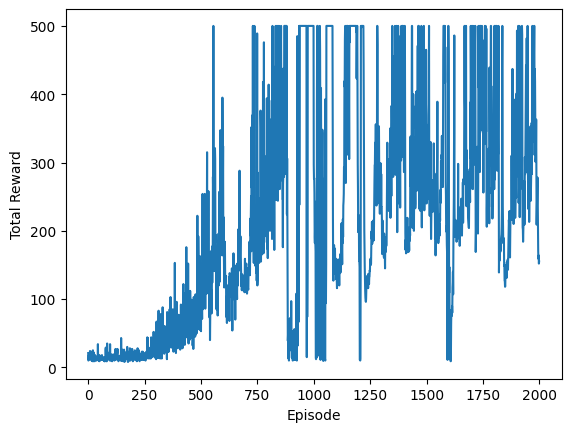

In [6]:
def plot_total_reward(reward_history):
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.plot(range(len(reward_history)), reward_history)
    plt.show()

plot_total_reward(reward_history)